In [ ]:
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path_data = '/content/drive/MyDrive/tesis_monica/afasia/data/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#CATALAN
df = pd.read_csv(path_data + 'df_transcrip_chunk_info.csv', encoding='utf-8')

df["name_chunk_audio_path"] = df["name_chunk_audio_path"].str.replace(
    "/Users/monicaromero/PycharmProjects/afasia_cat/audios_chunks/",
    "/content/drive/MyDrive/tesis_monica/afasia/data/aphasibank_es/",
    regex=False
)

df.head()

,Inicio,Fin,Marca,Transcrip_name,Duración,name_chunk_audio,name_chunk_audio_path,CIP,NumId,Gènere,...,Edat,Grup,QA,Fluente/No Fluente,num_palabras,num_palabras_unicas,promedio_palabras_por_frase,num_ininteligibles,palabras_por_minuto,palabras_por_segundo
0,0.00000,2.32800,IL,02_008_CAT_Conversacion,2.32800,02_008_CAT_Conversacion_0.00000_2.32800.wav,/content/drive/MyDrive/tesis_monica/afasia/dat...,02_008,8,1,...,71,2,82.6,Fluente,1,1,1.0,1,25.773196,0.429553
1,0.41390,4.65332,n'hi ha una casa en un cotxe en la porta,02_007_CAT_Lamina,4.23942,02_007_CAT_Lamina_0.41390_4.65332.wav,/content/drive/MyDrive/tesis_monica/afasia/dat...,02_007,7,2,...,53,2,41.8,No Fluente,10,9,10.0,0,141.528794,2.358813
2,0.94175,2.84395,vale,02_002_CAT_Lamina,1.90220,02_002_CAT_Lamina_0.94175_2.84395.wav,/content/drive/MyDrive/tesis_monica/afasia/dat...,02_002,2,2,...,83,1,46.8,Fluente,1,1,1.0,0,31.542425,0.525707
3,2.40829,3.47078,cotxe,02_007_CAT_Lamina,1.06249,02_007_CAT_Lamina_2.40829_3.47078.wav,/content/drive/MyDrive/tesis_monica/afasia/dat...,02_007,7,2,...,53,2,41.8,No Fluente,1,1,1.0,0,56.471120,0.941185
4,2.69463,6.79340,ahora IL mi filla esta,02_008_CAT_Conversacion,4.09877,02_008_CAT_Conversacion_2.69463_6.79340.wav,/content/drive/MyDrive/tesis_monica/afasia/dat...,02_008,8,1,...,71,2,82.6,Fluente,5,5,5.0,1,73.192690,1.219878


In [ ]:
#APHASIABANK
df_aphbank = pd.read_csv(path_data + 'df_aphasiabank_all.csv', encoding='utf-8')
df_aphbank.head()

,Inicio,Fin,Marca,sex,Edat,Transcrip_name,QA,aphasia_type,name_chunk_audio,fluency_speech,Grup,Duración,Gènere,TipusAfàsia,Fluente/No Fluente,LLengWAB,CIP,name_chunk_audio_path
0,9430.0,12876.0,yeah well <lau>,female,69.0,ACWT01a.wav,63.9,Broca,ACWT01a_9.43_3.446.wav,Non Fluent,Moderate,3446.0,2.0,1.0,No Fluente,2,ACWT01a,/content/drive/MyDrive/tesis_monica/afasia/dat...
1,15181.0,20445.0,i yeah you know <flr> <flr> <flr> <lau>,female,69.0,ACWT01a.wav,63.9,Broca,ACWT01a_15.181_5.264.wav,Non Fluent,Moderate,5264.0,2.0,1.0,No Fluente,2,ACWT01a,/content/drive/MyDrive/tesis_monica/afasia/dat...
2,24756.0,33655.0,yes <flr> it's two thousand two days,female,69.0,ACWT01a.wav,63.9,Broca,ACWT01a_24.756_8.899.wav,Non Fluent,Moderate,8899.0,2.0,1.0,No Fluente,2,ACWT01a,/content/drive/MyDrive/tesis_monica/afasia/dat...
3,33655.0,34070.0,no,female,69.0,ACWT01a.wav,63.9,Broca,ACWT01a_33.655_0.415.wav,Non Fluent,Moderate,415.0,2.0,1.0,No Fluente,2,ACWT01a,/content/drive/MyDrive/tesis_monica/afasia/dat...
4,34070.0,43822.0,after <flr> new year's day two thousand,female,69.0,ACWT01a.wav,63.9,Broca,ACWT01a_34.07_9.752.wav,Non Fluent,Moderate,9752.0,2.0,1.0,No Fluente,2,ACWT01a,/content/drive/MyDrive/tesis_monica/afasia/dat...


# Nuevas variables

contar_palabras(texto): número total de palabras en la transcripción

palabras_unicas(texto): numero de palabras únicas en la transcripción

promedio_palabras_por_frase(texto): promedio de palabras por transcripción

contar_ininteligibles(texto): numero de veces que aparece "IL" en la transcripción (ininteligibilidad)

palabras_por_minuto(num_palabras, duracion): tasa de palabras por minuto

palabras_por_segundo(num_palabras, duracion): tasa de palabras por segundo

In [ ]:
 def contar_palabras(texto):
    """Total number of words in the transcription."""
    return len(texto.split())

def palabras_unicas(texto):
    """Number of unique words in the transcription."""
    return len(set(texto.split()))

def promedio_palabras_por_frase(texto):
    """Average number of words per sentence in the transcription."""
    frases = texto.split('.')  # Split by periods to count sentences
    num_frases = len(frases)
    num_palabras = contar_palabras(texto)
    return num_palabras / num_frases if num_frases > 0 else 0

def contar_ininteligibles(texto):
    """Number of times 'IL' appears in the transcription."""
    return texto.count("IL")  # Count how many times "IL" appears

def palabras_por_minuto(num_palabras, duracion):
    """Rate of words per minute."""
    return (num_palabras / duracion) * 60 if duracion > 0 else 0

def palabras_por_segundo(num_palabras, duracion):
    """Rate of words per second."""
    return num_palabras / duracion if duracion > 0 else 0

def contar_ininteligibles_aphasiabank(texto):
    """
    Counts the total occurrences of specific unintelligible labels in the transcription.
    These labels include: flr (fillers), spn (spoken noises), brth (breathing sounds).

    Args:
        texto (str): The transcription text.

    Returns:
        int: Total count of all unintelligible labels.
    """
    labels = ['flr', 'spn', 'brth']
    total_count = sum(texto.lower().count(label) for label in labels)
    return total_count

In [ ]:
# Catalan dataset
df['num_palabras'] = df['Marca'].apply(contar_palabras)
df['num_palabras_unicas'] = df['Marca'].apply(palabras_unicas)
df['promedio_palabras_por_frase'] = df['Marca'].apply(promedio_palabras_por_frase)
df['num_ininteligibles'] = df['Marca'].apply(contar_ininteligibles)
df['palabras_por_minuto'] = df.apply(lambda x: palabras_por_minuto(x['num_palabras'], x['Duración']), axis=1)
df['palabras_por_segundo'] = df.apply(lambda x: palabras_por_segundo(x['num_palabras'], x['Duración']), axis=1)
df.head()

,Inicio,Fin,Marca,Transcrip_name,Duración,name_chunk_audio,name_chunk_audio_path,CIP,NumId,Gènere,...,Edat,Grup,QA,Fluente/No Fluente,num_palabras,num_palabras_unicas,promedio_palabras_por_frase,num_ininteligibles,palabras_por_minuto,palabras_por_segundo
0,0.00000,2.32800,IL,02_008_CAT_Conversacion,2.32800,02_008_CAT_Conversacion_0.00000_2.32800.wav,/content/drive/MyDrive/tesis_monica/afasia/dat...,02_008,8,1,...,71,2,82.6,Fluente,1,1,1.0,1,25.773196,0.429553
1,0.41390,4.65332,n'hi ha una casa en un cotxe en la porta,02_007_CAT_Lamina,4.23942,02_007_CAT_Lamina_0.41390_4.65332.wav,/content/drive/MyDrive/tesis_monica/afasia/dat...,02_007,7,2,...,53,2,41.8,No Fluente,10,9,10.0,0,141.528794,2.358813
2,0.94175,2.84395,vale,02_002_CAT_Lamina,1.90220,02_002_CAT_Lamina_0.94175_2.84395.wav,/content/drive/MyDrive/tesis_monica/afasia/dat...,02_002,2,2,...,83,1,46.8,Fluente,1,1,1.0,0,31.542425,0.525707
3,2.40829,3.47078,cotxe,02_007_CAT_Lamina,1.06249,02_007_CAT_Lamina_2.40829_3.47078.wav,/content/drive/MyDrive/tesis_monica/afasia/dat...,02_007,7,2,...,53,2,41.8,No Fluente,1,1,1.0,0,56.471120,0.941185
4,2.69463,6.79340,ahora IL mi filla esta,02_008_CAT_Conversacion,4.09877,02_008_CAT_Conversacion_2.69463_6.79340.wav,/content/drive/MyDrive/tesis_monica/afasia/dat...,02_008,8,1,...,71,2,82.6,Fluente,5,5,5.0,1,73.192690,1.219878


In [ ]:
#aphasiabank dataset
df_aphbank['num_palabras'] = df_aphbank['Marca'].apply(contar_palabras)
df_aphbank['num_palabras_unicas'] = df_aphbank['Marca'].apply(palabras_unicas)
df_aphbank['promedio_palabras_por_frase'] = df_aphbank['Marca'].apply(promedio_palabras_por_frase)
df_aphbank['num_ininteligibles'] = df_aphbank['Marca'].apply(contar_ininteligibles_aphasiabank)
df_aphbank['palabras_por_minuto'] = df_aphbank.apply(lambda x: palabras_por_minuto(x['num_palabras'], x['Duración']), axis=1)
df_aphbank['palabras_por_segundo'] = df_aphbank.apply(lambda x: palabras_por_segundo(x['num_palabras'], x['Duración']), axis=1)
df_aphbank.head()

,Inicio,Fin,Marca,sex,Edat,Transcrip_name,QA,aphasia_type,name_chunk_audio,fluency_speech,...,Fluente/No Fluente,LLengWAB,CIP,name_chunk_audio_path,num_palabras,num_palabras_unicas,promedio_palabras_por_frase,num_ininteligibles,palabras_por_minuto,palabras_por_segundo
0,9430.0,12876.0,yeah well <lau>,female,69.0,ACWT01a.wav,63.9,Broca,ACWT01a_9.43_3.446.wav,Non Fluent,...,No Fluente,2,ACWT01a,/content/drive/MyDrive/tesis_monica/afasia/dat...,3,3,3.0,0,0.052234,0.000871
1,15181.0,20445.0,i yeah you know <flr> <flr> <flr> <lau>,female,69.0,ACWT01a.wav,63.9,Broca,ACWT01a_15.181_5.264.wav,Non Fluent,...,No Fluente,2,ACWT01a,/content/drive/MyDrive/tesis_monica/afasia/dat...,8,6,8.0,3,0.091185,0.001520
2,24756.0,33655.0,yes <flr> it's two thousand two days,female,69.0,ACWT01a.wav,63.9,Broca,ACWT01a_24.756_8.899.wav,Non Fluent,...,No Fluente,2,ACWT01a,/content/drive/MyDrive/tesis_monica/afasia/dat...,7,6,7.0,1,0.047196,0.000787
3,33655.0,34070.0,no,female,69.0,ACWT01a.wav,63.9,Broca,ACWT01a_33.655_0.415.wav,Non Fluent,...,No Fluente,2,ACWT01a,/content/drive/MyDrive/tesis_monica/afasia/dat...,1,1,1.0,0,0.144578,0.002410
4,34070.0,43822.0,after <flr> new year's day two thousand,female,69.0,ACWT01a.wav,63.9,Broca,ACWT01a_34.07_9.752.wav,Non Fluent,...,No Fluente,2,ACWT01a,/content/drive/MyDrive/tesis_monica/afasia/dat...,7,7,7.0,1,0.043068,0.000718


# ANALISIS DEL DATASET

# Catalan

In [ ]:
df.describe()

,Inicio,Fin,Duración,NumId,Gènere,TipusAfàsia,LLengWAB,Edat,Grup,QA,num_palabras,num_palabras_unicas,promedio_palabras_por_frase,num_ininteligibles,palabras_por_minuto,palabras_por_segundo
count,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000
mean,111.539406,114.353890,2.814484,5.217311,1.701657,4.248619,1.458564,63.005525,1.405157,60.723020,2.418048,2.366483,2.418048,0.149171,67.454762,1.124246
std,77.787278,77.795052,3.916317,2.092138,0.457953,2.209271,0.498740,10.121857,0.491375,24.749209,2.178435,2.075187,2.178435,0.356586,51.440683,0.857345
min,0.000000,2.328000,1.000470,1.000000,1.000000,1.000000,1.000000,52.000000,1.000000,34.700000,1.000000,1.000000,1.000000,0.000000,0.880525,0.014675
25%,48.255605,51.475095,1.396865,3.000000,1.000000,1.000000,1.000000,53.000000,1.000000,41.800000,1.000000,1.000000,1.000000,0.000000,31.210884,0.520181
50%,95.431510,97.282720,1.958630,5.000000,2.000000,5.000000,1.000000,67.000000,1.000000,44.300000,1.000000,1.000000,1.000000,0.000000,50.033356,0.833889
75%,164.290610,167.834015,2.954040,7.000000,2.000000,6.000000,2.000000,68.000000,2.000000,87.700000,3.000000,3.000000,3.000000,0.000000,97.688574,1.628143
max,314.631510,316.000000,68.141150,8.000000,2.000000,6.000000,2.000000,83.000000,2.000000,96.700000,13.000000,13.000000,13.000000,1.000000,293.106144,4.885102


In [ ]:
categorical_columns = ['Marca', 'Transcrip_name', 'Gènere', 'TipusAfàsia', 'Fluente/No Fluente']
for col in categorical_columns:
    print(f"Distribución de valores en '{col}':\n{df[col].value_counts()}\n")

Distribución de valores en 'Marca':
Marca
IL                               68
i                                19
no                                9
bastant                           8
un                                8
                                 ..
porque se van a caer              1
una capsa de carto de sabates     1
jo soc molt de meter              1
d'un senyor que n'hi ha alli      1
es que                            1
Name: count, Length: 360, dtype: int64

Distribución de valores en 'Transcrip_name':
Transcrip_name
02_007_CAT_Conversacion            118
01_004_CAT__parla_espontania        92
01_003_CAT_Llenguatge_espontani     81
02_007_CAT_Lamina                   65
01_007_CAT_Parla_espontania         49
01_005_CAT_llenguatge_espontani     42
02_008_CAT_Conversacion             37
01_001_CAT_descripcio lamina        30
02_002_CAT_Lamina                   19
02_002_CAT__Conversacion             6
02_003_CAT_Lamina                    4
Name: count, dtype: int64

Distri

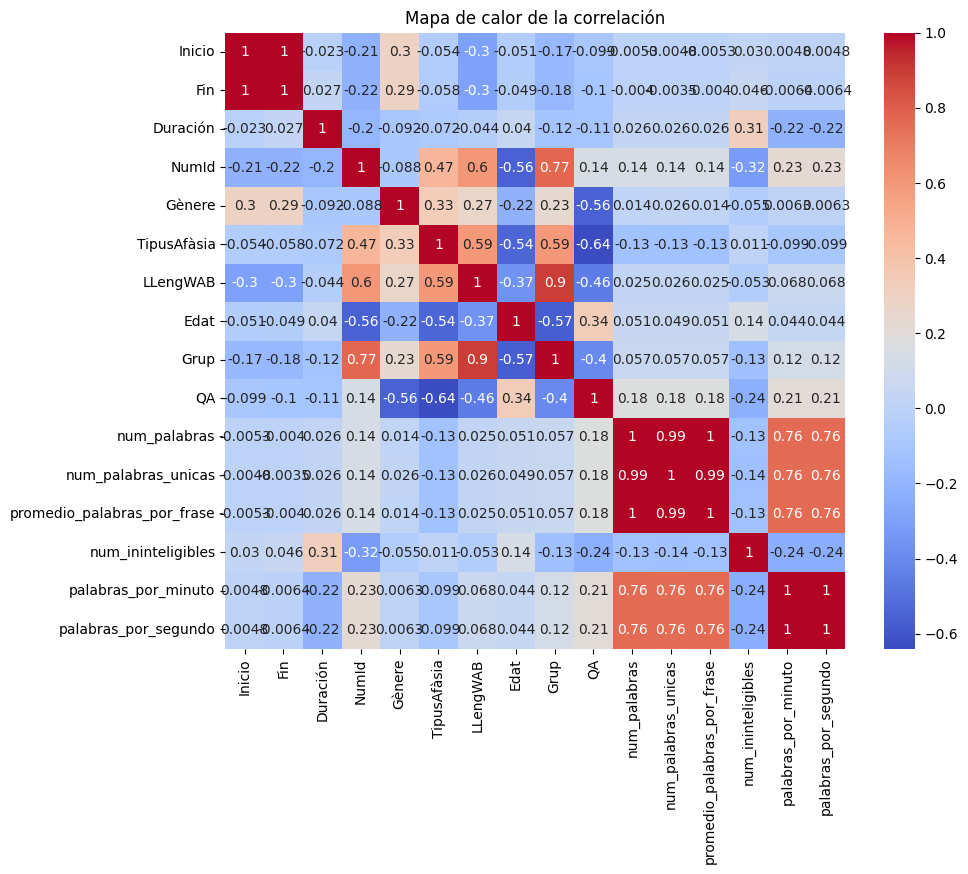

In [ ]:
numerical_data = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_data.corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de calor de la correlación')
plt.show()

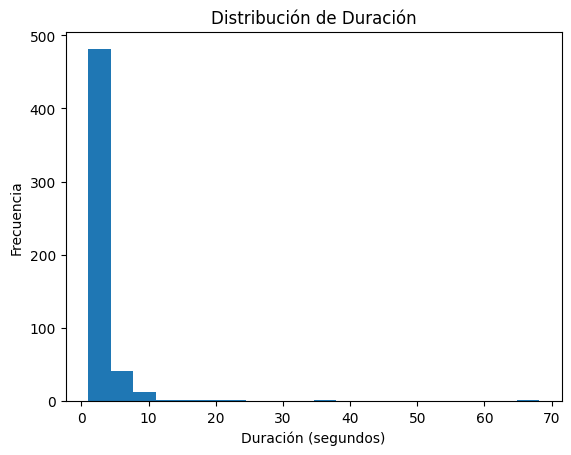

In [ ]:
# Histograma de la duración de los audios
plt.hist(df['Duración'], bins=20)
plt.title('Distribución de Duración')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')
plt.show()

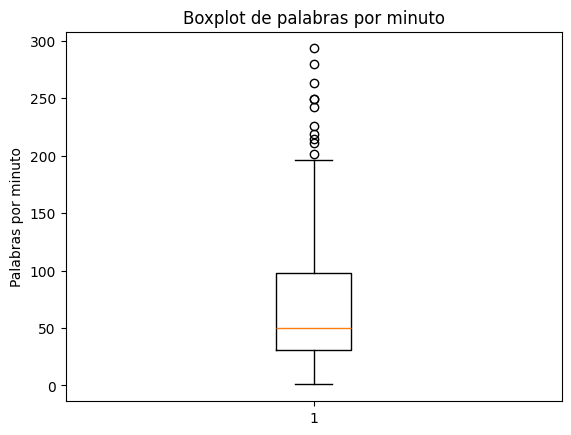

In [ ]:
# Boxplot de palabras por minuto
plt.boxplot(df['palabras_por_minuto'])
plt.title('Boxplot de palabras por minuto')
plt.ylabel('Palabras por minuto')
plt.show()

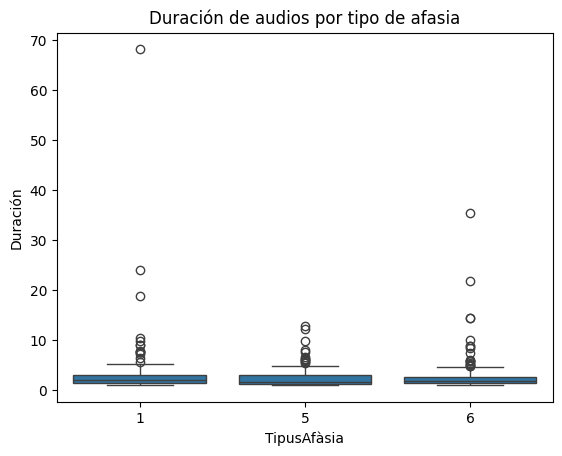

In [ ]:
# Comparación de duraciones por tipo de afasia
sns.boxplot(x='TipusAfàsia', y='Duración', data=df)
plt.title('Duración de audios por tipo de afasia')
plt.show()

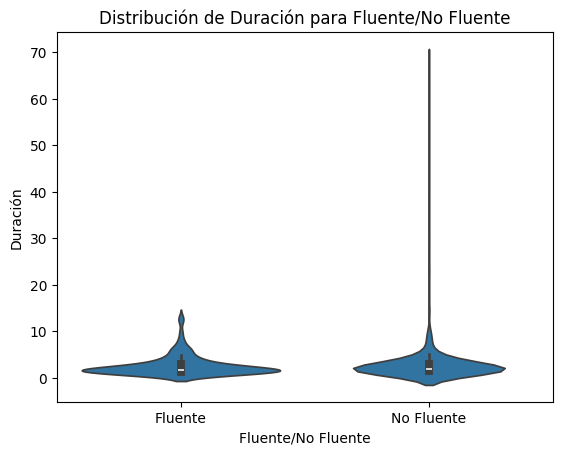

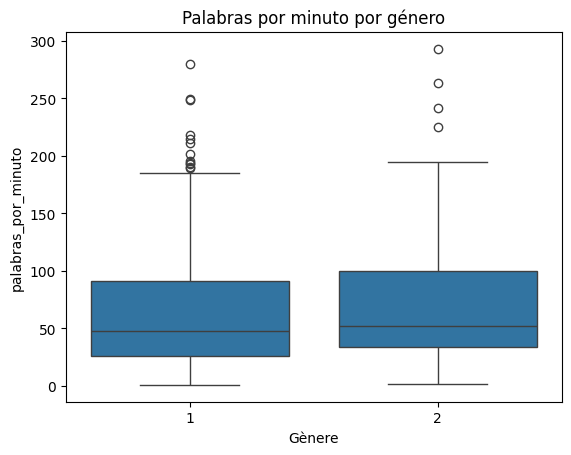

In [ ]:
# Comparación entre Fluente/No Fluente y Duración
sns.violinplot(x='Fluente/No Fluente', y='Duración', data=df)
plt.title('Distribución de Duración para Fluente/No Fluente')
plt.show()

# Comparación de género en función de palabras por minuto
sns.boxplot(x='Gènere', y='palabras_por_minuto', data=df)
plt.title('Palabras por minuto por género')
plt.show()

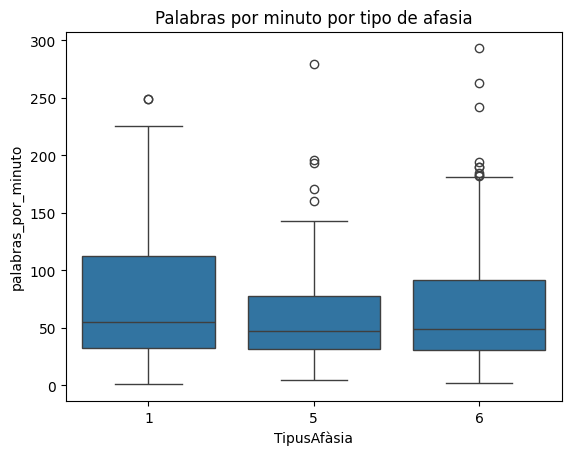

In [ ]:
# Comparar palabras por minuto entre tipos de afasia
sns.boxplot(x='TipusAfàsia', y='palabras_por_minuto', data=df)
plt.title('Palabras por minuto por tipo de afasia')
plt.show()

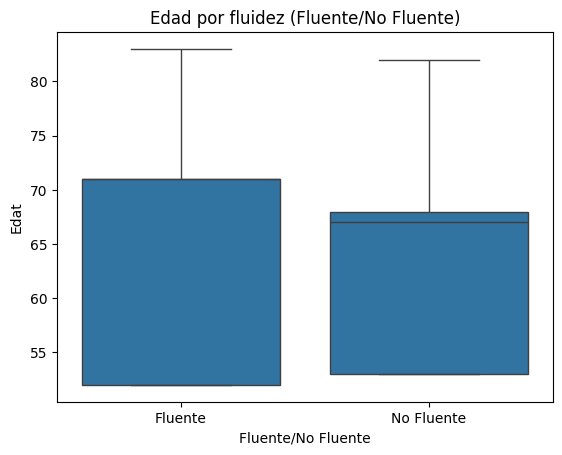

In [ ]:
# Comparar la edad según fluidez
sns.boxplot(x='Fluente/No Fluente', y='Edat', data=df)
plt.title('Edad por fluidez (Fluente/No Fluente)')
plt.show()


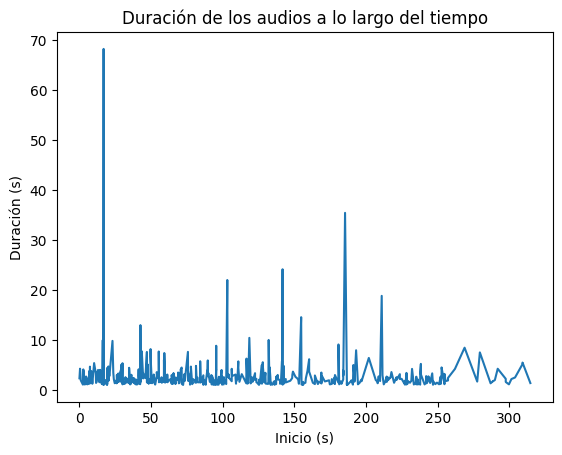

In [ ]:
df.sort_values(by='Inicio', inplace=True)
plt.plot(df['Inicio'], df['Duración'])
plt.xlabel('Inicio (s)')
plt.ylabel('Duración (s)')
plt.title('Duración de los audios a lo largo del tiempo')
plt.show()

### NULO Catalan

In [ ]:
total_transcripciones = len(df)
num_no_fluentes = df['Fluente/No Fluente'].value_counts().get('No Fluente', 0)
num_fluentes = df['Fluente/No Fluente'].value_counts().get('Fluente', 0)

p_nf = num_no_fluentes / total_transcripciones  # prob no fluente
p_f = num_fluentes / total_transcripciones      # prob fluente

# precision teorica del modelo nulo
precision_esperada = p_nf**2 + p_f**2
print(f'precision teorica esperada del modelo nulo: {precision_esperada:.4f}')

# simulacion estocastica del modelo nulo
n_simulaciones = 1000
resultados = []

for _ in range(n_simulaciones):
    # predicciones aleatorias basadas en p_nf y p_f
    predicciones_aleatorias = np.random.choice(['No Fluente', 'Fluente'], size=total_transcripciones, p=[p_nf, p_f])

    correctas = (predicciones_aleatorias == df['Fluente/No Fluente']).sum()
    precision_simulada = correctas / total_transcripciones
    resultados.append(precision_simulada)

precision_promedio_simulada = np.mean(resultados)
print(f'precision promedio simulada del modelo nulo: {precision_promedio_simulada:.4f}')

precision teorica esperada del modelo nulo: 0.6747
precision promedio simulada del modelo nulo: 0.6748


In [ ]:
conteo_clases = df['Fluente/No Fluente'].value_counts()
clase_mayoritaria = conteo_clases.idxmax()  # identifica clase mayoritaria -> no fluente
num_clase_mayoritaria = conteo_clases.max()  # veces que aparece no fluente , 432
total_transcripciones = len(df) # 543

precision_mayoria = num_clase_mayoritaria / total_transcripciones
print(f'precision esperada del modelo nulo que elige la clase mayoritaria: {precision_mayoria:.4f}')

print(f'clase mayoritaria: {clase_mayoritaria} (se predice siempre esta clase)')

precision esperada del modelo nulo que elige la clase mayoritaria: 0.7956
clase mayoritaria: No Fluente (se predice siempre esta clase)


Superar el 67.4% indica que el modelo es mejor que hacer predicciones al azar.

Superar el 79.56% indica que el modelo es mejor que simplemente predecir "No Fluente" siempre.

# Analisis dataset Aphasiabank

In [ ]:
df_aphbank.describe()

,Inicio,Fin,Edat,QA,Duración,Gènere,TipusAfàsia,LLengWAB,num_palabras,num_palabras_unicas,promedio_palabras_por_frase,num_ininteligibles,palabras_por_minuto,palabras_por_segundo
count,7.739700e+04,7.739700e+04,76507.000000,70823.000000,77397.000000,77074.000000,70776.000000,77422.0,77422.000000,77422.000000,77422.000000,77422.000000,77422.000000,77422.000000
mean,7.145813e+05,7.194410e+05,61.845465,72.692092,4806.058796,1.410696,3.721558,2.0,6.797499,5.511005,6.797499,0.962918,1.075534,0.017926
std,5.854276e+05,5.858950e+05,12.066840,17.964410,5226.613161,0.491963,2.169177,0.0,5.838232,4.107027,5.838232,1.625106,10.932376,0.182206
min,0.000000e+00,1.000000e+03,25.000000,10.800000,0.237000,1.000000,0.000000,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.776620e+05,2.821270e+05,54.000000,61.400000,1526.000000,1.000000,1.000000,2.0,3.000000,2.000000,3.000000,0.000000,0.060060,0.001001
50%,5.821000e+05,5.867770e+05,62.000000,76.300000,3143.000000,1.000000,4.000000,2.0,5.000000,5.000000,5.000000,0.000000,0.099622,0.001660
75%,9.953250e+05,1.000699e+06,70.000000,87.200000,6208.000000,2.000000,5.000000,2.0,9.000000,8.000000,9.000000,1.000000,0.152866,0.002548
max,4.425695e+06,4.428269e+06,91.000000,99.600000,121819.000000,2.000000,7.000000,2.0,90.000000,48.000000,90.000000,33.000000,622.406639,10.373444


In [ ]:
categorical_columns = ['Marca', 'Transcrip_name', 'Gènere', 'TipusAfàsia', 'Fluente/No Fluente']
for col in categorical_columns:
    print(f"Distribución de valores en '{col}':\n{df_aphbank[col].value_counts()}\n")

Distribución de valores en 'Marca':
Marca
okay                                                                2244
yeah                                                                1676
yes                                                                  839
no                                                                   795
mhm                                                                  571
                                                                    ... 
and they had a good time                                               1
and they they had a little <flr> <flr> <flr> <flr> little things       1
and then though her time came up                                       1
her time came up to be oer                                             1
y juntelo y ya está                                                    1
Name: count, Length: 58717, dtype: int64

Distribución de valores en 'Transcrip_name':
Transcrip_name
elman12a.wav       670
ACWT09a.wav        659
elman14

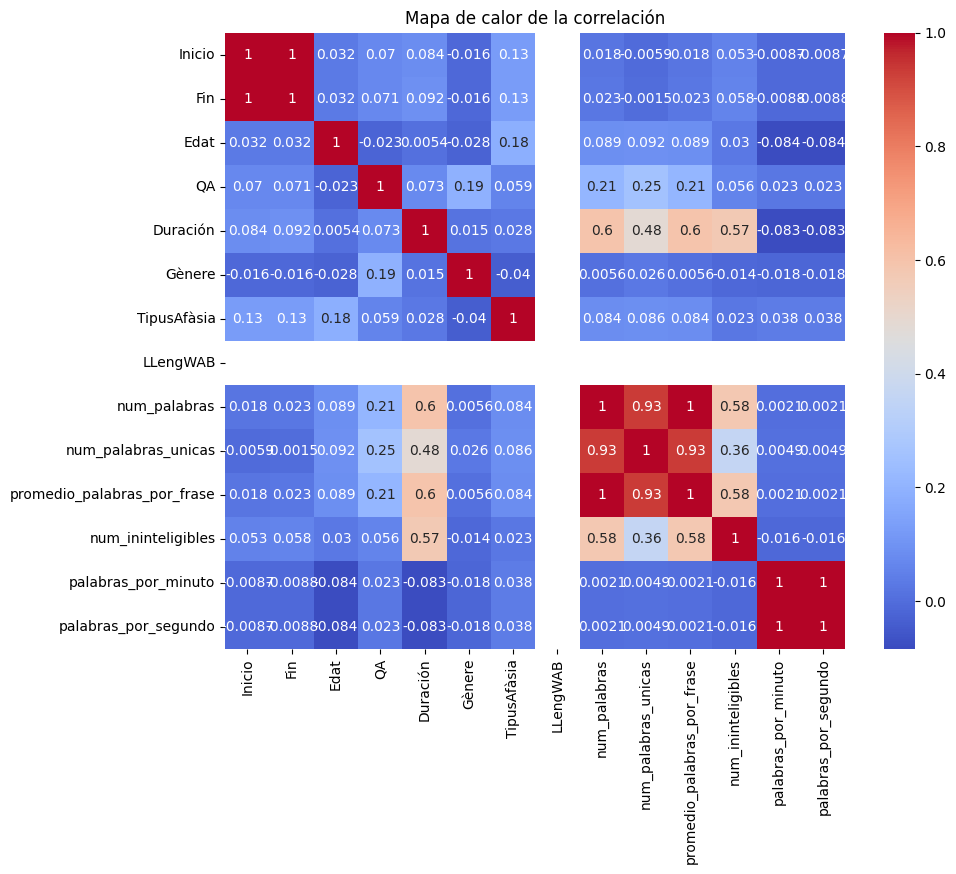

In [ ]:
numerical_data = df_aphbank.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_data.corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de calor de la correlación')
plt.show()

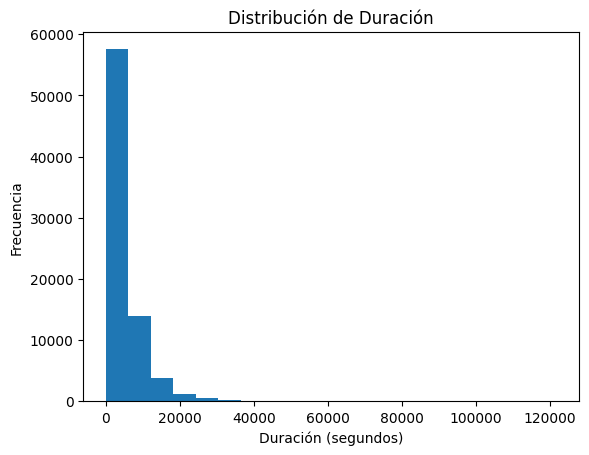

In [ ]:
# Histograma de la duración de los audios
plt.hist(df_aphbank['Duración'], bins=20)
plt.title('Distribución de Duración')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
# # Boxplot de palabras por minuto
# plt.boxplot(df_aphbank['palabras_por_minuto'])
# plt.title('Boxplot de palabras por minuto')
# plt.ylabel('Palabras por minuto')
# plt.show()

In [ ]:
# # Comparación de duraciones por tipo de afasia
# sns.boxplot(x='TipusAfàsia', y='Duración', data=df_aphbank)
# plt.title('Duración de audios por tipo de afasia')
# plt.show()

In [ ]:
# # Comparación entre Fluente/No Fluente y Duración
# sns.violinplot(x='Fluente/No Fluente', y='Duración', data=df_aphbank)
# plt.title('Distribución de Duración para Fluente/No Fluente')
# plt.show()
#
# # Comparación de género en función de palabras por minuto
# sns.boxplot(x='Gènere', y='palabras_por_minuto', data=df_aphbank)
# plt.title('Palabras por minuto por género')
# plt.show()

In [ ]:
# # Comparar palabras por minuto entre tipos de afasia
# sns.boxplot(x='TipusAfàsia', y='palabras_por_minuto', data=df_aphbank)
# plt.title('Palabras por minuto por tipo de afasia')
# plt.show()

In [ ]:
# # Comparar la edad según fluidez
# sns.boxplot(x='Fluente/No Fluente', y='Edat', data=df_aphbank)
# plt.title('Edad por fluidez (Fluente/No Fluente)')
# plt.show()

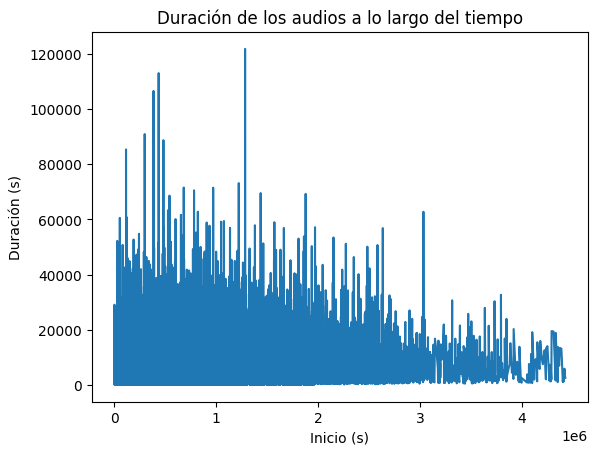

In [ ]:
df_aphbank.sort_values(by='Inicio', inplace=True)
plt.plot(df_aphbank['Inicio'], df_aphbank['Duración'])
plt.xlabel('Inicio (s)')
plt.ylabel('Duración (s)')
plt.title('Duración de los audios a lo largo del tiempo')
plt.show()

### NULO Aphasiabank

In [ ]:
total_transcripciones = len(df_aphbank)
num_no_fluentes = df_aphbank['Fluente/No Fluente'].value_counts().get('No Fluente', 0)
num_fluentes = df_aphbank['Fluente/No Fluente'].value_counts().get('Fluente', 0)

p_nf = num_no_fluentes / total_transcripciones  # prob no fluente
p_f = num_fluentes / total_transcripciones      # prob fluente

# precision teorica del modelo nulo
precision_esperada = p_nf**2 + p_f**2
print(f'precision teorica esperada del modelo nulo: {precision_esperada:.4f}')

# Normalizar las probabilidades para asegurarse de que sumen exactamente 1
suma_probabilidades = p_nf + p_f
p_nf_normalizado = p_nf / suma_probabilidades
p_f_normalizado = p_f / suma_probabilidades

# Simulación estocástica del modelo nulo
n_simulaciones = 1000
resultados = []

for _ in range(n_simulaciones):
    # Predicciones aleatorias basadas en probabilidades normalizadas
    predicciones_aleatorias = np.random.choice(['No Fluente', 'Fluente'], size=total_transcripciones, p=[p_nf_normalizado, p_f_normalizado])

    correctas = (predicciones_aleatorias == df_aphbank['Fluente/No Fluente']).sum()
    precision_simulada = correctas / total_transcripciones
    resultados.append(precision_simulada)

precision_promedio_simulada = np.mean(resultados)
print(f'Precisión promedio simulada del modelo nulo: {precision_promedio_simulada:.4f}')


precision teorica esperada del modelo nulo: 0.4271
Precisión promedio simulada del modelo nulo: 0.5161


In [ ]:
conteo_clases = df_aphbank['Fluente/No Fluente'].value_counts()
clase_mayoritaria = conteo_clases.idxmax()  # identifica clase mayoritaria -> no fluente
num_clase_mayoritaria = conteo_clases.max()  # veces que aparece no fluente , 432
total_transcripciones = len(df_aphbank) # 543

precision_mayoria = num_clase_mayoritaria / total_transcripciones
print(f'precision esperada del modelo nulo que elige la clase mayoritaria: {precision_mayoria:.4f}')

print(f'clase mayoritaria: {clase_mayoritaria} (se predice siempre esta clase)')

precision esperada del modelo nulo que elige la clase mayoritaria: 0.6194
clase mayoritaria: Fluente (se predice siempre esta clase)


Superar el 29.48% indica que el modelo es mejor que hacer predicciones al azar.

Superar el 54.29% indica que el modelo es mejor que simplemente predecir "No Fluente" siempre.

In [ ]:
df.to_csv(path_data + 'df_transcrip_chunk_info.csv', index=False, encoding='utf-8')

In [ ]:
df_aphbank.to_csv(path_data + 'df_aphbank_transcrip_chunk_info.csv', index=False, encoding='utf-8')